# Part 3: Tonic-Phasic Decomposition
Computing trial-level vigor summaries and examining how tonic baseline, phasic encounter response, and terminal vigor vary by condition.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
VIGOR_PROC = ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_processed'
VIGOR_PREP = ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_prep'
FIGS_DIR = ROOT / 'figs'
FIGS_DIR.mkdir(parents=True, exist_ok=True)
DPI = 150

# ── Load & filter ─────────────────────────────────────────────────────────────
df_raw = pd.read_parquet(VIGOR_PROC / 'smoothed_vigor_ts.parquet')

# Harmonize column names (new pipeline → old naming convention used throughout)
if 'subj' in df_raw.columns and 'subj_id' not in df_raw.columns:
    df_raw = df_raw.rename(columns={'subj': 'subj_id', 'trial': 'trial_id'})
_rename = {
    'isAttackTrial': 'encounter', 'encounterTime': 'encounter_time',
    'trialEscapeTime': 'escape_time', 'trialCaptureTime': 'capture_time',
    'trialEndTime': 'trial_end_time', 'vigor_norm': 'v_t',
}
df_raw = df_raw.rename(columns={k: v for k, v in _rename.items() if k in df_raw.columns})

# Merge effort_L and calibrationMax (f_max_i) from trial_events
_te = pd.read_parquet(VIGOR_PREP / 'trial_events.parquet')
_te = _te.rename(columns={'subj': 'subj_id', 'trial': 'trial_id', 'calibrationMax': 'f_max_i'})
df_raw = df_raw.merge(_te[['subj_id', 'trial_id', 'effort_L', 'f_max_i']], on=['subj_id', 'trial_id'], how='left')

df_raw['trial_type'] = 1  # all stage5 data passed QC
df = df_raw[df_raw['trial_type'] == 1].copy()
print(f'Loaded: {df_raw.shape[0]:,} rows total')
print(f'After trial_type==1 filter: {df.shape[0]:,} rows')
print(f'Subjects: {df["subj_id"].nunique()}, '
      f'Subject-trials: {df.groupby(["subj_id", "trial_id"]).ngroups:,}')

# ── Color palettes ────────────────────────────────────────────────────────────
THREAT_COLORS = {0.1: '#2ca02c', 0.5: '#ff7f0e', 0.9: '#d62728'}
CHOICE_COLORS = {0: 'steelblue', 1: 'darkorange'}
DISTANCE_COLORS = {1: '#aec7e8', 2: '#1f77b4', 3: '#08306b'}

# ── Compute terminal_time per trial ───────────────────────────────────────────
# outcome=0 -> escaped (use escape_time)
# outcome=1 -> captured (use capture_time)
# outcome=-1 -> timed out (use trial_end_time)
df['terminal_time'] = np.where(
    df['outcome'] == 0, df['escape_time'],
    np.where(df['outcome'] == 1, df['capture_time'], df['trial_end_time'])
)

# ── Compute r_min per trial ───────────────────────────────────────────────────
# choice=0 -> low cookie -> r_min = effort_L
# choice=1 -> high cookie -> r_min = effort_H
df['r_min'] = np.where(df['choice'] == 0, df['effort_L'], df['effort_H'])

# ── Build trial_info (one row per subj_id x trial_id) ────────────────────────
trial_info = df.groupby(['subj_id', 'trial_id']).agg(
    threat=('threat', 'first'),
    choice=('choice', 'first'),
    outcome=('outcome', 'first'),
    encounter=('encounter', 'first'),
    encounter_time=('encounter_time', 'first'),
    escape_time=('escape_time', 'first'),
    capture_time=('capture_time', 'first'),
    trial_end_time=('trial_end_time', 'first'),
    terminal_time=('terminal_time', 'first'),
    r_min=('r_min', 'first'),
    startDistance=('startDistance', 'first'),
    distance_H=('distance_H', 'first'),
    effort_L=('effort_L', 'first'),
    effort_H=('effort_H', 'first'),
    f_max_i=('f_max_i', 'first'),
).reset_index()

print(f'\ntrial_info: {trial_info.shape[0]:,} trials')
print(f'Outcome distribution:\n{trial_info["outcome"].value_counts().sort_index()}')

Loaded: 2,005,694 rows total
After trial_type==1 filter: 2,005,694 rows
Subjects: 293, Subject-trials: 23,556

trial_info: 23,556 trials
Outcome distribution:
outcome
0    16413
1     7143
Name: count, dtype: int64


## Computing Trial-Level Summaries
Extract tonic, phasic, and terminal vigor measures for each trial.

In [2]:
# ── Compute trial-level summaries ─────────────────────────────────────────────

def compute_trial_summaries(group):
    """Compute tonic, phasic, and terminal summaries for one trial."""
    t = group['t'].values
    v = group['v_t'].values
    # c_it (cumulative keypresses per bin) is optional — not in new pipeline parquet
    has_c = 'c_it' in group.columns
    c = group['c_it'].values if has_c else None

    # Trial-level info (constant within group)
    enc_time = group['encounter_time'].iloc[0]
    encounter = group['encounter'].iloc[0]
    term_time = group['terminal_time'].iloc[0]

    result = {}

    # ── Overall ────────────────────────────────────────────────────────────
    result['trial_vigor'] = np.nanmean(v)

    # ── Tonic vigor ────────────────────────────────────────────────────────
    # Window: [0.5s, min(encounter_time, 2.5s) - 0.5s]
    tonic_start = 0.5
    tonic_end = min(enc_time, 2.5) - 0.5
    tonic_mask = (t >= tonic_start) & (t <= tonic_end)

    tonic_window_dur = tonic_end - tonic_start
    result['tonic_valid'] = tonic_window_dur >= 1.0

    if tonic_mask.sum() > 0:
        result['tonic_mean'] = np.nanmean(v[tonic_mask])
        result['tonic_median_c'] = np.nanmedian(c[tonic_mask]) if has_c else np.nan
        result['duty_cycle'] = np.nanmean(c[tonic_mask] > 0) if has_c else np.nan
    else:
        result['tonic_mean'] = np.nan
        result['tonic_median_c'] = np.nan
        result['duty_cycle'] = np.nan

    # ── Phasic (attack trials only) ────────────────────────────────────────
    if encounter == 1:
        phasic_start = enc_time
        phasic_end = enc_time + 2.0
        phasic_mask = (t >= phasic_start) & (t <= phasic_end)

        if phasic_mask.sum() > 0:
            v_phasic = v[phasic_mask]
            t_phasic = t[phasic_mask]
            tonic_baseline = result['tonic_mean'] if not np.isnan(result.get('tonic_mean', np.nan)) else 0.0
            result['phasic_peak'] = np.nanmax(v_phasic) - tonic_baseline
            peak_idx = np.nanargmax(v_phasic)
            result['phasic_latency'] = t_phasic[peak_idx] - enc_time
            result['phasic_sustained'] = np.nanmean(v_phasic) - tonic_baseline
        else:
            result['phasic_peak'] = np.nan
            result['phasic_latency'] = np.nan
            result['phasic_sustained'] = np.nan
    else:
        result['phasic_peak'] = np.nan
        result['phasic_latency'] = np.nan
        result['phasic_sustained'] = np.nan

    # ── Terminal vigor ─────────────────────────────────────────────────────
    if term_time > 1.5:
        term_start = term_time - 1.5
        term_end = term_time
        term_mask = (t >= term_start) & (t <= term_end)
        if term_mask.sum() > 0:
            result['terminal_mean'] = np.nanmean(v[term_mask])
        else:
            result['terminal_mean'] = np.nan
    else:
        result['terminal_mean'] = np.nan

    return pd.Series(result)


print('Computing trial-level summaries (this may take a minute)...')
trial_summaries = df.groupby(['subj_id', 'trial_id']).apply(
    compute_trial_summaries, include_groups=False
).reset_index()

# ── Merge with trial_info ─────────────────────────────────────────────────────
trial_summary = trial_info.merge(trial_summaries, on=['subj_id', 'trial_id'], how='left')

# Ensure boolean column
trial_summary['tonic_valid'] = trial_summary['tonic_valid'].astype(bool)

print(f'trial_summary: {trial_summary.shape}')
print(f'Columns: {list(trial_summary.columns)}')

# ── Save ──────────────────────────────────────────────────────────────────────
out_path = VIGOR_PROC / 'trial_level_summaries.parquet'
trial_summary.to_parquet(out_path, index=False)
print(f'Saved to {out_path}')

Computing trial-level summaries (this may take a minute)...


trial_summary: (23556, 26)
Columns: ['subj_id', 'trial_id', 'threat', 'choice', 'outcome', 'encounter', 'encounter_time', 'escape_time', 'capture_time', 'trial_end_time', 'terminal_time', 'r_min', 'startDistance', 'distance_H', 'effort_L', 'effort_H', 'f_max_i', 'trial_vigor', 'tonic_valid', 'tonic_mean', 'tonic_median_c', 'duty_cycle', 'phasic_peak', 'phasic_latency', 'phasic_sustained', 'terminal_mean']
Saved to /Users/nokada/Desktop/EffortForagingUnderThreat/data/exploratory_350/processed/vigor_processed/trial_level_summaries.parquet


=== Descriptive statistics ===
       tonic_mean  tonic_median_c  duty_cycle  phasic_peak  phasic_latency  phasic_sustained  terminal_mean  trial_vigor
count  15110.0000             0.0         0.0   11697.0000      11697.0000        11697.0000     21858.0000   23556.0000
mean       0.3863             NaN         NaN       0.7005          1.2006            0.3834         0.8513       0.6684
std        0.3787             NaN         NaN       0.5720          0.6836            0.4120         0.3616       0.2313
min        0.0000             NaN         NaN      -0.9580          0.0000           -1.1694         0.0000       0.0090
25%        0.0000             NaN         NaN       0.1519          0.6090            0.0001         0.7237       0.5505
50%        0.3382             NaN         NaN       0.7366          1.3334            0.3267         0.9003       0.6620
75%        0.6738             NaN         NaN       1.1042          1.8800            0.6787         1.0090       0.7664
m

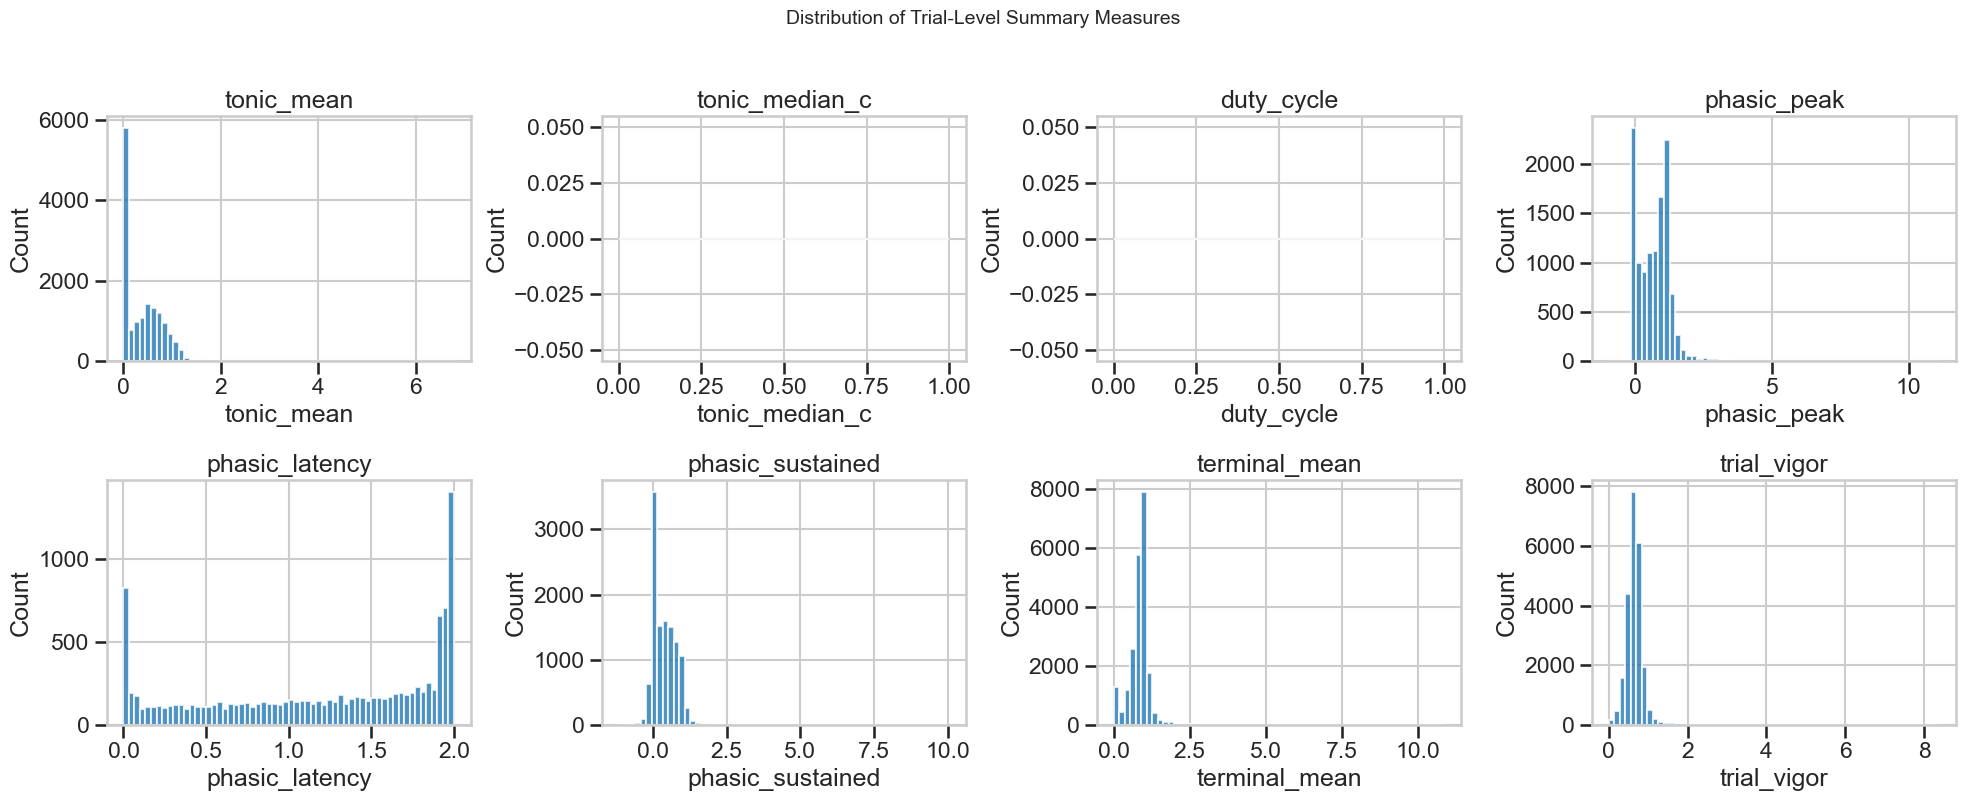

In [3]:
# ── Inspect trial summaries ───────────────────────────────────────────────────

summary_cols = ['tonic_mean', 'tonic_median_c', 'duty_cycle',
                'phasic_peak', 'phasic_latency', 'phasic_sustained',
                'terminal_mean', 'trial_vigor']

print('=== Descriptive statistics ===')
print(trial_summary[summary_cols].describe().round(4).to_string())

print('\n=== NaN counts ===')
print(trial_summary[summary_cols].isna().sum())

print(f'\n=== Tonic valid trials: {trial_summary["tonic_valid"].sum()} / {len(trial_summary)} '
      f'({100 * trial_summary["tonic_valid"].mean():.1f}%) ===')

print(f'\n=== Attack trials (encounter==1): {(trial_summary["encounter"]==1).sum()} ===')
print(f'=== Non-attack trials (encounter==0): {(trial_summary["encounter"]==0).sum()} ===')

# Quick histograms of the key measures
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.ravel(), summary_cols):
    vals = trial_summary[col].dropna()
    ax.hist(vals, bins=60, edgecolor='white', alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.suptitle('Distribution of Trial-Level Summary Measures', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Figure 8: Tonic Vigor by Condition

Using 8,630 tonic-valid trials


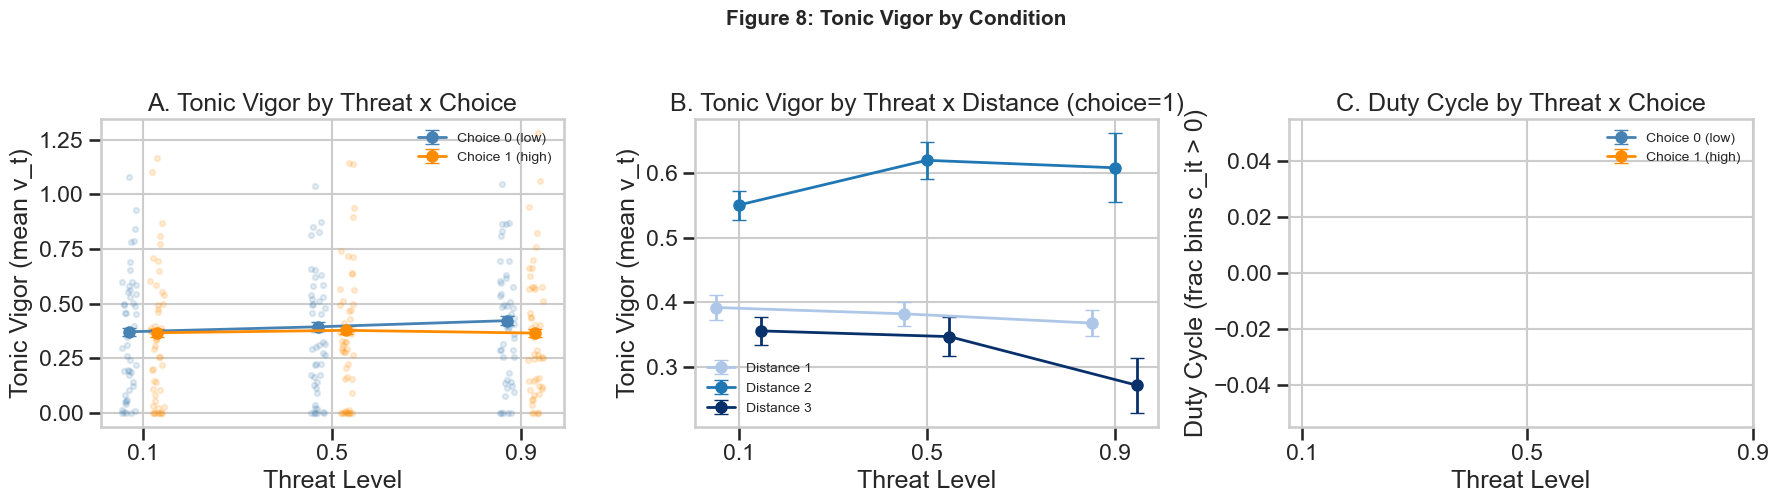

Saved fig08_tonic_vigor.png


In [4]:
# ── Figure 8: Tonic Vigor by Condition ────────────────────────────────────────

# Use only tonic-valid trials
ts_valid = trial_summary[trial_summary['tonic_valid']].copy()
print(f'Using {len(ts_valid):,} tonic-valid trials')

# ── Helper: compute subject-level means, then group SEM ──────────────────────
def subject_means_and_sem(data, value_col, group_cols):
    """Compute subject means first, then SEM across subjects."""
    subj_means = data.groupby(['subj_id'] + group_cols)[value_col].mean().reset_index()
    agg = subj_means.groupby(group_cols)[value_col].agg(['mean', 'std', 'count']).reset_index()
    agg['sem'] = agg['std'] / np.sqrt(agg['count'])
    return agg


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel A: Tonic vigor by threat x choice ──────────────────────────────────
ax = axes[0]
agg_a = subject_means_and_sem(ts_valid, 'tonic_mean', ['threat', 'choice'])

threats = sorted(ts_valid['threat'].unique())
width = 0.15
offsets = {0: -width / 2, 1: width / 2}

# Subsample subjects for jittered dots
np.random.seed(42)
all_subjs = ts_valid['subj_id'].unique()
dot_subjs = np.random.choice(all_subjs, size=min(50, len(all_subjs)), replace=False)
dot_data = ts_valid[ts_valid['subj_id'].isin(dot_subjs)]
dot_subj_means = dot_data.groupby(['subj_id', 'threat', 'choice'])['tonic_mean'].mean().reset_index()

for ch in [0, 1]:
    sub = agg_a[agg_a['choice'] == ch]
    x_pos = np.arange(len(threats)) + offsets[ch]
    label = f'Choice {ch} ({"low" if ch == 0 else "high"})'
    ax.errorbar(x_pos, sub['mean'], yerr=sub['sem'],
                fmt='o-', color=CHOICE_COLORS[ch], capsize=5,
                markersize=8, linewidth=2, label=label, zorder=5)

    # Jittered individual dots
    dot_sub = dot_subj_means[dot_subj_means['choice'] == ch]
    for i, thr in enumerate(threats):
        vals = dot_sub[dot_sub['threat'] == thr]['tonic_mean']
        jitter = np.random.uniform(-0.04, 0.04, size=len(vals))
        ax.scatter(np.full(len(vals), i + offsets[ch]) + jitter, vals,
                   color=CHOICE_COLORS[ch], alpha=0.15, s=15, zorder=2)

ax.set_xticks(range(len(threats)))
ax.set_xticklabels(threats)
ax.set_xlabel('Threat Level')
ax.set_ylabel('Tonic Vigor (mean v_t)')
ax.set_title('A. Tonic Vigor by Threat x Choice')
ax.legend(fontsize=10)

# ── Panel B: Tonic vigor by threat x distance (choice=1 only) ────────────────
ax = axes[1]
ts_high = ts_valid[ts_valid['choice'] == 1].copy()
agg_b = subject_means_and_sem(ts_high, 'tonic_mean', ['threat', 'distance_H'])

distances = sorted(ts_high['distance_H'].unique())
n_dist = len(distances)
dist_offsets = {d: (i - (n_dist - 1) / 2) * 0.12 for i, d in enumerate(distances)}

for dist in distances:
    sub = agg_b[agg_b['distance_H'] == dist]
    x_pos = np.arange(len(threats)) + dist_offsets[dist]
    ax.errorbar(x_pos, sub['mean'], yerr=sub['sem'],
                fmt='o-', color=DISTANCE_COLORS.get(dist, 'gray'), capsize=5,
                markersize=8, linewidth=2, label=f'Distance {int(dist)}', zorder=5)

ax.set_xticks(range(len(threats)))
ax.set_xticklabels(threats)
ax.set_xlabel('Threat Level')
ax.set_ylabel('Tonic Vigor (mean v_t)')
ax.set_title('B. Tonic Vigor by Threat x Distance (choice=1)')
ax.legend(fontsize=10)

# ── Panel C: Duty cycle by threat x choice ───────────────────────────────────
ax = axes[2]
agg_c = subject_means_and_sem(ts_valid, 'duty_cycle', ['threat', 'choice'])

# Jitter dots for duty cycle
dot_subj_dc = dot_data.groupby(['subj_id', 'threat', 'choice'])['duty_cycle'].mean().reset_index()

for ch in [0, 1]:
    sub = agg_c[agg_c['choice'] == ch]
    x_pos = np.arange(len(threats)) + offsets[ch]
    label = f'Choice {ch} ({"low" if ch == 0 else "high"})'
    ax.errorbar(x_pos, sub['mean'], yerr=sub['sem'],
                fmt='o-', color=CHOICE_COLORS[ch], capsize=5,
                markersize=8, linewidth=2, label=label, zorder=5)

    # Jittered individual dots
    dot_sub = dot_subj_dc[dot_subj_dc['choice'] == ch]
    for i, thr in enumerate(threats):
        vals = dot_sub[dot_sub['threat'] == thr]['duty_cycle']
        jitter = np.random.uniform(-0.04, 0.04, size=len(vals))
        ax.scatter(np.full(len(vals), i + offsets[ch]) + jitter, vals,
                   color=CHOICE_COLORS[ch], alpha=0.15, s=15, zorder=2)

ax.set_xticks(range(len(threats)))
ax.set_xticklabels(threats)
ax.set_xlabel('Threat Level')
ax.set_ylabel('Duty Cycle (frac bins c_it > 0)')
ax.set_title('C. Duty Cycle by Threat x Choice')
ax.legend(fontsize=10)

plt.suptitle('Figure 8: Tonic Vigor by Condition', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(FIGS_DIR / 'fig08_tonic_vigor.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved fig08_tonic_vigor.png')

## Figure 9: Phasic Amplitude by Condition (Attack Trials Only)

Attack trials with phasic data: 11,697


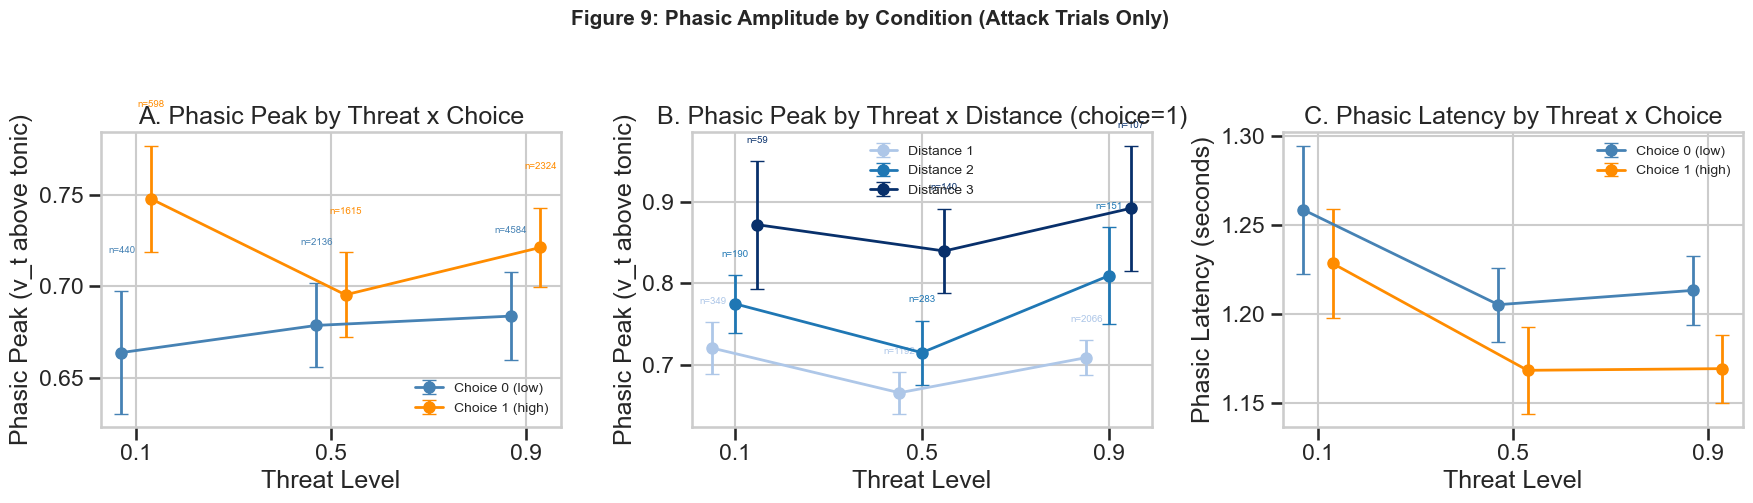

Saved fig09_phasic_amplitude.png


In [5]:
# ── Figure 9: Phasic Amplitude by Condition (Attack Trials Only) ──────────────

ts_attack = trial_summary[(trial_summary['encounter'] == 1) &
                          trial_summary['phasic_peak'].notna()].copy()
print(f'Attack trials with phasic data: {len(ts_attack):,}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel A: Phasic peak by threat x choice ──────────────────────────────────
ax = axes[0]
agg_a = subject_means_and_sem(ts_attack, 'phasic_peak', ['threat', 'choice'])

for ch in [0, 1]:
    sub = agg_a[agg_a['choice'] == ch]
    x_pos = np.arange(len(threats)) + offsets[ch]
    label = f'Choice {ch} ({"low" if ch == 0 else "high"})'
    ax.errorbar(x_pos, sub['mean'], yerr=sub['sem'],
                fmt='o-', color=CHOICE_COLORS[ch], capsize=5,
                markersize=8, linewidth=2, label=label, zorder=5)

# Print N per cell
n_per_cell = ts_attack.groupby(['threat', 'choice']).size().reset_index(name='N')
for _, row in n_per_cell.iterrows():
    thr_idx = threats.index(row['threat'])
    ch = int(row['choice'])
    x = thr_idx + offsets[ch]
    y_max = agg_a.loc[(agg_a['threat'] == row['threat']) & (agg_a['choice'] == ch), 'mean'].values[0]
    y_sem = agg_a.loc[(agg_a['threat'] == row['threat']) & (agg_a['choice'] == ch), 'sem'].values[0]
    ax.text(x, y_max + y_sem + 0.02, f'n={int(row["N"])}',
            ha='center', va='bottom', fontsize=7, color=CHOICE_COLORS[ch])

ax.set_xticks(range(len(threats)))
ax.set_xticklabels(threats)
ax.set_xlabel('Threat Level')
ax.set_ylabel('Phasic Peak (v_t above tonic)')
ax.set_title('A. Phasic Peak by Threat x Choice')
ax.legend(fontsize=10)

# ── Panel B: Phasic peak by threat x distance (choice=1 only) ────────────────
ax = axes[1]
ts_attack_high = ts_attack[ts_attack['choice'] == 1].copy()
agg_b = subject_means_and_sem(ts_attack_high, 'phasic_peak', ['threat', 'distance_H'])

for dist in distances:
    sub = agg_b[agg_b['distance_H'] == dist]
    x_pos = np.arange(len(threats)) + dist_offsets[dist]
    ax.errorbar(x_pos, sub['mean'], yerr=sub['sem'],
                fmt='o-', color=DISTANCE_COLORS.get(dist, 'gray'), capsize=5,
                markersize=8, linewidth=2, label=f'Distance {int(dist)}', zorder=5)

# Print N per cell
n_per_cell_b = ts_attack_high.groupby(['threat', 'distance_H']).size().reset_index(name='N')
for _, row in n_per_cell_b.iterrows():
    thr_idx = threats.index(row['threat'])
    dist = row['distance_H']
    x = thr_idx + dist_offsets[dist]
    y_val = agg_b.loc[(agg_b['threat'] == row['threat']) & (agg_b['distance_H'] == dist), 'mean'].values[0]
    y_err = agg_b.loc[(agg_b['threat'] == row['threat']) & (agg_b['distance_H'] == dist), 'sem'].values[0]
    ax.text(x, y_val + y_err + 0.02, f'n={int(row["N"])}',
            ha='center', va='bottom', fontsize=7,
            color=DISTANCE_COLORS.get(dist, 'gray'))

ax.set_xticks(range(len(threats)))
ax.set_xticklabels(threats)
ax.set_xlabel('Threat Level')
ax.set_ylabel('Phasic Peak (v_t above tonic)')
ax.set_title('B. Phasic Peak by Threat x Distance (choice=1)')
ax.legend(fontsize=10)

# ── Panel C: Phasic latency by threat x choice ───────────────────────────────
ax = axes[2]
agg_c = subject_means_and_sem(ts_attack, 'phasic_latency', ['threat', 'choice'])

for ch in [0, 1]:
    sub = agg_c[agg_c['choice'] == ch]
    x_pos = np.arange(len(threats)) + offsets[ch]
    label = f'Choice {ch} ({"low" if ch == 0 else "high"})'
    ax.errorbar(x_pos, sub['mean'], yerr=sub['sem'],
                fmt='o-', color=CHOICE_COLORS[ch], capsize=5,
                markersize=8, linewidth=2, label=label, zorder=5)

ax.set_xticks(range(len(threats)))
ax.set_xticklabels(threats)
ax.set_xlabel('Threat Level')
ax.set_ylabel('Phasic Latency (seconds)')
ax.set_title('C. Phasic Latency by Threat x Choice')
ax.legend(fontsize=10)

plt.suptitle('Figure 9: Phasic Amplitude by Condition (Attack Trials Only)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(FIGS_DIR / 'fig09_phasic_amplitude.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved fig09_phasic_amplitude.png')

## Figure 10: Tonic-Phasic Relationship
Are tonic and phasic vigor independent or coupled?

Trials with both tonic and phasic: 7,366
Overall Pearson r = -0.682, p = 0.00e+00

Per-threat correlations:
  Threat 0.1: r = -0.702, p = 2.35e-105, n = 703
  Threat 0.5: r = -0.708, p = 0.00e+00, n = 2379
  Threat 0.9: r = -0.667, p = 0.00e+00, n = 4284


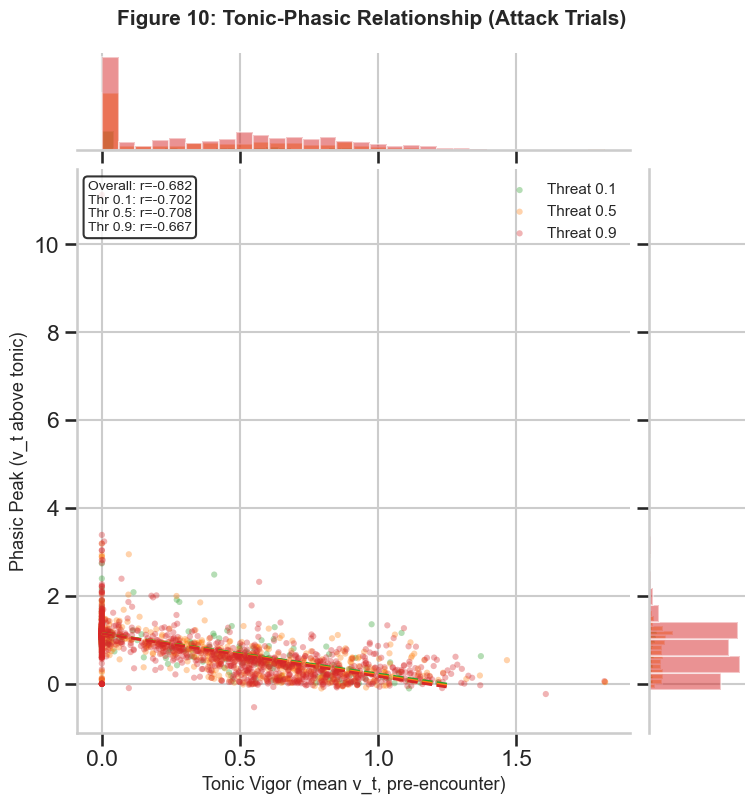

Saved fig10_tonic_phasic_scatter.png


In [6]:
# ── Figure 10: Tonic-Phasic Relationship ─────────────────────────────────────
from scipy import stats

# Filter to attack trials with both tonic and phasic measures
scatter_df = trial_summary[
    (trial_summary['encounter'] == 1) &
    trial_summary['tonic_mean'].notna() &
    trial_summary['phasic_peak'].notna()
].copy()
print(f'Trials with both tonic and phasic: {len(scatter_df):,}')

# Subsample for readability
np.random.seed(123)
n_plot = min(2000, len(scatter_df))
scatter_sub = scatter_df.sample(n=n_plot, random_state=123)

# ── Overall Pearson correlation ──────────────────────────────────────────────
r_all, p_all = stats.pearsonr(scatter_df['tonic_mean'], scatter_df['phasic_peak'])
print(f'Overall Pearson r = {r_all:.3f}, p = {p_all:.2e}')

# ── Per-threat correlations ──────────────────────────────────────────────────
print('\nPer-threat correlations:')
corr_results = {}
for thr in sorted(scatter_df['threat'].unique()):
    sub = scatter_df[scatter_df['threat'] == thr]
    r, p = stats.pearsonr(sub['tonic_mean'], sub['phasic_peak'])
    corr_results[thr] = (r, p, len(sub))
    print(f'  Threat {thr}: r = {r:.3f}, p = {p:.2e}, n = {len(sub)}')

# ── Build JointGrid ──────────────────────────────────────────────────────────
g = sns.JointGrid(data=scatter_sub, x='tonic_mean', y='phasic_peak', height=8)

# Main scatter: color by threat
for thr in sorted(scatter_sub['threat'].unique()):
    sub = scatter_sub[scatter_sub['threat'] == thr]
    g.ax_joint.scatter(sub['tonic_mean'], sub['phasic_peak'],
                       color=THREAT_COLORS[thr], alpha=0.35, s=20,
                       label=f'Threat {thr}', edgecolors='none')

# Linear fit per threat (on full data, not subsample)
x_range = np.linspace(scatter_df['tonic_mean'].quantile(0.01),
                      scatter_df['tonic_mean'].quantile(0.99), 100)
for thr in sorted(scatter_df['threat'].unique()):
    sub = scatter_df[scatter_df['threat'] == thr]
    slope, intercept = np.polyfit(sub['tonic_mean'], sub['phasic_peak'], 1)
    g.ax_joint.plot(x_range, slope * x_range + intercept,
                    color=THREAT_COLORS[thr], linewidth=2, linestyle='--')

g.ax_joint.set_xlabel('Tonic Vigor (mean v_t, pre-encounter)', fontsize=13)
g.ax_joint.set_ylabel('Phasic Peak (v_t above tonic)', fontsize=13)
g.ax_joint.legend(fontsize=11, loc='upper right')

# Add correlation text
txt = f'Overall: r={r_all:.3f}\n'
for thr, (r, p, n) in corr_results.items():
    txt += f'Thr {thr}: r={r:.3f}\n'
g.ax_joint.text(0.02, 0.98, txt.strip(), transform=g.ax_joint.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Marginal histograms colored by threat
for thr in sorted(scatter_sub['threat'].unique()):
    sub = scatter_sub[scatter_sub['threat'] == thr]
    g.ax_marg_x.hist(sub['tonic_mean'], bins=30, alpha=0.5,
                     color=THREAT_COLORS[thr], edgecolor='white')
    g.ax_marg_y.hist(sub['phasic_peak'], bins=30, alpha=0.5,
                     color=THREAT_COLORS[thr], edgecolor='white',
                     orientation='horizontal')

g.fig.suptitle('Figure 10: Tonic-Phasic Relationship (Attack Trials)',
               fontsize=15, fontweight='bold', y=1.02)
g.fig.savefig(FIGS_DIR / 'fig10_tonic_phasic_scatter.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved fig10_tonic_phasic_scatter.png')

## Summary
Key findings from tonic-phasic decomposition.